In [1]:
import numpy as np
import matplotlib.pyplot as plt

# A reproducible random-number generator (same numbers every run).
rng = np.random.default_rng(0)

## Chapter 02a — Plotting Functions & Data

A picture turns a formula into intuition. In this notebook we use
**Matplotlib**, the standard plotting library, together with **NumPy** (from
Chapter 01) to draw functions and data.

The recipe is almost always the same three steps:

1. Build an array of $x$ values with `np.linspace`.
2. Compute the matching $y$ values with a vectorised formula, e.g. `np.sin(x)`.
3. Hand `(x, y)` to `plt.plot` and decorate the picture (title, labels, grid).

___
### 2. Your first plot: a function on a grid

To draw $f(x) = \sin(x)$ we need many closely-spaced $x$ values.
`np.linspace(a, b, n)` returns `n` evenly spaced points from `a` to `b`
(both endpoints included). NumPy then evaluates `np.sin` on all of them at once.

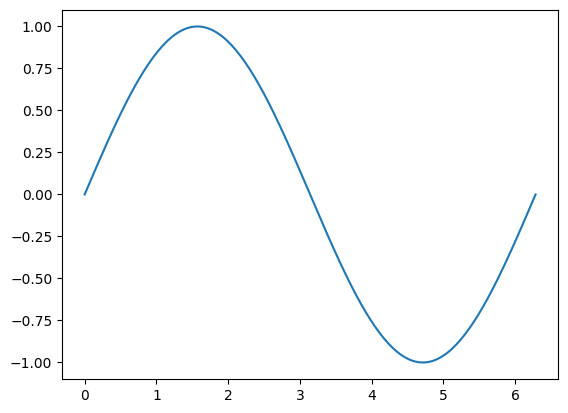

In [2]:
x = np.linspace(0, 2 * np.pi, 200)   # 200 points from 0 to 2*pi
y = np.sin(x)                        # one y for every x, all at once

plt.plot(x, y)        # connect the (x, y) points with a line
plt.show()            # render the figure

The smooth curve is really 200 tiny straight segments — with enough points the
eye sees a smooth sine wave. More points = smoother curve.  // Make it 10 pts to see d jadded lines btwn d points.

____
### 3. Decorating a plot: title, labels, grid

A plot without labels is a riddle. Always say **what** is on each axis.

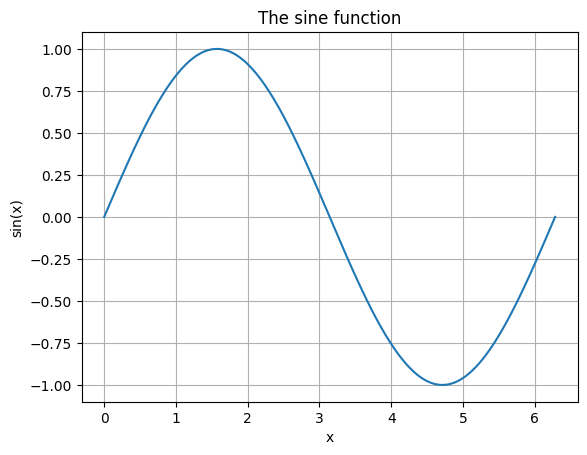

In [3]:
x = np.linspace(0, 2 * np.pi, 200)
y = np.sin(x)

plt.plot(x, y)
plt.title("The sine function")   # heading above the plot
plt.xlabel("x")                  # label the horizontal axis
plt.ylabel("sin(x)")             # label the vertical axis
plt.grid(True)                   # add a light reference grid
plt.show()

___
### 4. Several curves on one axes + a legend

Just call `plt.plot` more than once before `plt.show()`. Give each curve a
`label`, then call `plt.legend()` so the reader knows which is which.

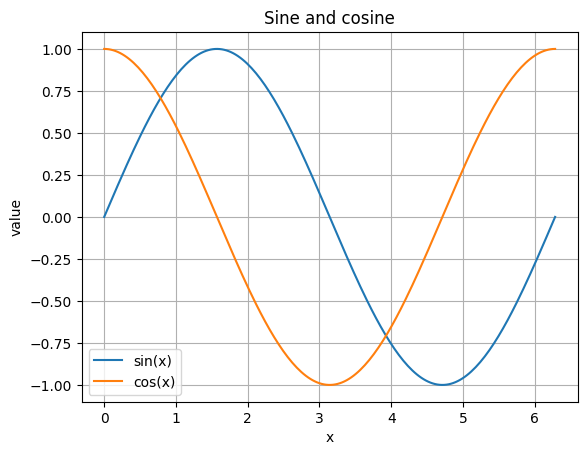

In [4]:
x = np.linspace(0, 2 * np.pi, 200)

plt.plot(x, np.sin(x), label="sin(x)")
plt.plot(x, np.cos(x), label="cos(x)")
plt.title("Sine and cosine")
plt.xlabel("x")
plt.ylabel("value")
plt.legend()          # show the box matching colors to labels
plt.grid(True)
plt.show()

____
### 5. Line styles and colors

You can control how each line looks. A short format string after the data sets
color and style, e.g. `"r--"` = red dashed. You can also pass keywords like
`color`, `linestyle`, and `linewidth`.

| Code | Meaning |
|------|---------|
| `"r"` `"g"` `"b"` `"k"` | red, green, blue, black |
| `"-"` `"--"` `":"` `"-."` | solid, dashed, dotted, dash-dot |
| `"o"` `"s"` `"^"` | circle, square, triangle markers |

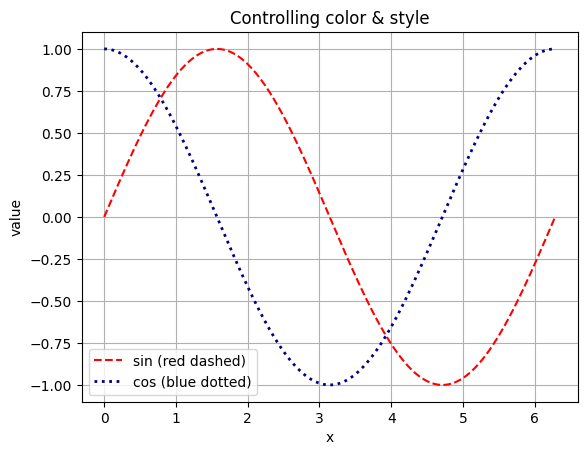

In [5]:
x = np.linspace(0, 2 * np.pi, 200)

plt.plot(x, np.sin(x), "r--", label="sin (red dashed)")
plt.plot(x, np.cos(x), color="navy", linestyle=":", linewidth=2,
         label="cos (blue dotted)")
plt.title("Controlling color & style")
plt.xlabel("x")
plt.ylabel("value")
plt.legend()
plt.grid(True)
plt.show()

___
### 6. Scatter plots: showing data points

When you have *data* (not a smooth function) you usually want dots, not a line.
`plt.scatter(x, y)` draws one marker per point. Here we make a noisy version of
the line $y = 2x + 1$ and scatter it against the true line.

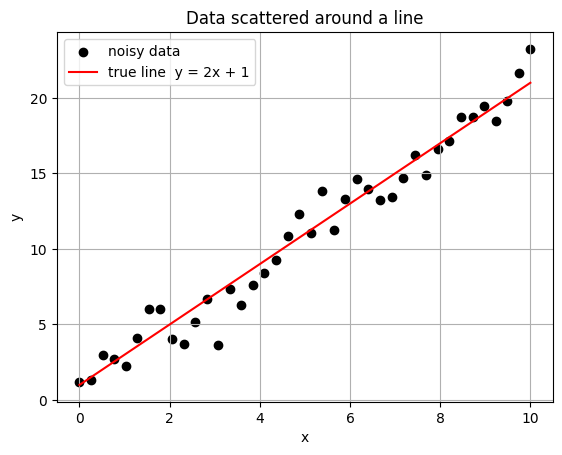

In [6]:
x = np.linspace(0, 10, 40)
true_y = 2 * x + 1                     # the underlying straight line
noise = rng.normal(0, 1.5, size=x.shape)   # random wobble, mean 0
data_y = true_y + noise                # measured/noisy data

plt.scatter(x, data_y, color="black", label="noisy data")
plt.plot(x, true_y, "r-", label="true line  y = 2x + 1")
plt.title("Data scattered around a line")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

____
### 7. Subplots: several panels in one figure

`plt.subplots(rows, cols)` returns a **figure** and an array of **axes**. Each
axes is its own little plot. Calling methods on an axes (`ax.plot`,
`ax.set_title`, ...) draws into that specific panel.

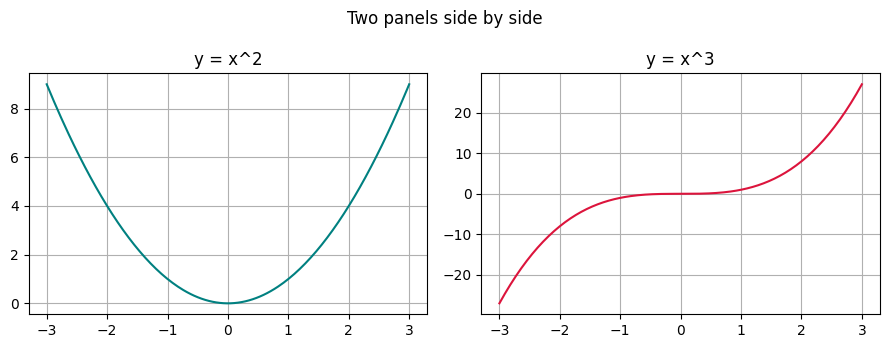

In [7]:
x = np.linspace(-3, 3, 200)

# A figure with 1 row, 2 columns of plots.
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

axes[0].plot(x, x**2, color="teal")
axes[0].set_title("y = x^2")
axes[0].grid(True)

axes[1].plot(x, x**3, color="crimson")
axes[1].set_title("y = x^3")
axes[1].grid(True)

fig.suptitle("Two panels side by side")
fig.tight_layout()    # stop the titles/labels from overlapping
plt.show()

___
### 8. Histograms: the shape of a distribution

A **histogram** sorts numbers into bins and draws a bar for how many landed in
each bin. It reveals the *shape* of a dataset. Here we draw 5000 samples from a
standard normal (bell curve) and let `plt.hist` count them.

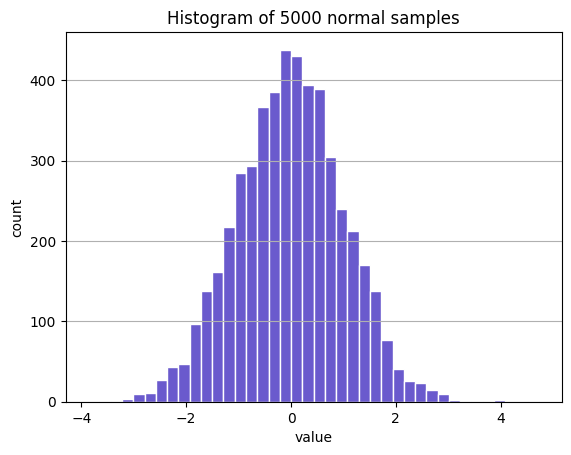

In [29]:
samples = rng.normal(0, 1, size=5000)   # mean = 0; sd = 1

plt.hist(samples, bins=40, color="slateblue", edgecolor="white")
plt.title("Histogram of 5000 normal samples")
plt.xlabel("value")
plt.ylabel("count")
plt.grid(True, axis="y")
plt.show()

____
### 9. Bar charts: comparing categories

`plt.bar` draws one bar per category — handy for counts and, later, for the
probabilities a classifier assigns to each class.

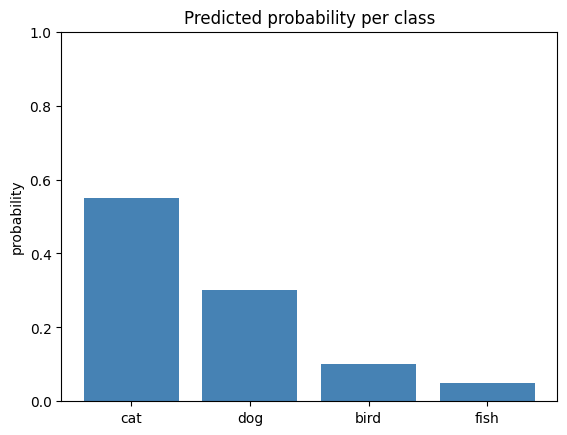

In [26]:
classes = ["cat", "dog", "bird", "fish"]
probs = [0.55, 0.30, 0.10, 0.05]

plt.bar(classes, probs, color="steelblue")
plt.title("Predicted probability per class")
plt.ylabel("probability")
plt.ylim(0, 1)
plt.show()

____
### 10. Annotations and shading

Two finishing touches you'll use a lot: `plt.fill_between` shades a region (the
area under a curve, or a confidence band), and `plt.annotate` points an arrow at
an interesting spot.

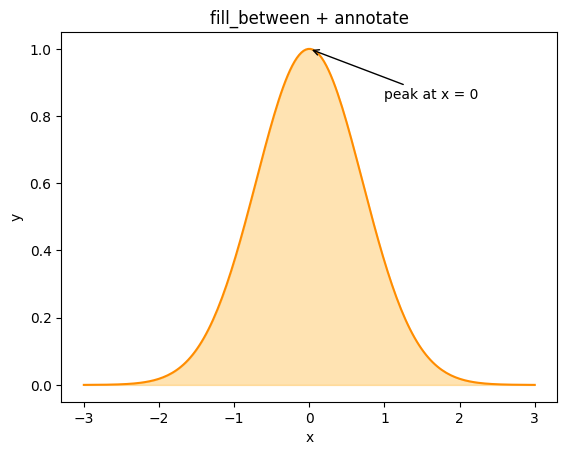

In [27]:
x = np.linspace(-3, 3, 200)
y = np.exp(-x**2)

plt.plot(x, y, color="darkorange")
plt.fill_between(x, y, alpha=0.3, color="orange")
plt.annotate("peak at x = 0", xy=(0, 1), xytext=(1.0, 0.85),
             arrowprops=dict(arrowstyle="->"))
plt.title("fill_between + annotate")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

* alpha=0.3 → transparency. 0 = invisible, 1 = fully opaque.
* xy=(0, 1) → the point being annotated. Here, the arrow points to (0, 1).
* xytext=(1.0, 0.85) → where the annotation text is placed.

---
### ✍️ Exercise 1 (solution included)

On the interval $[-2, 2]$ plot the parabola $f(x) = x^2$ and the line
$g(x) = 2x - 1$ on the **same axes**. Add a title, axis labels, a legend, and a
grid. (The line is the tangent to the parabola at $x = 1$ — notice they touch.)

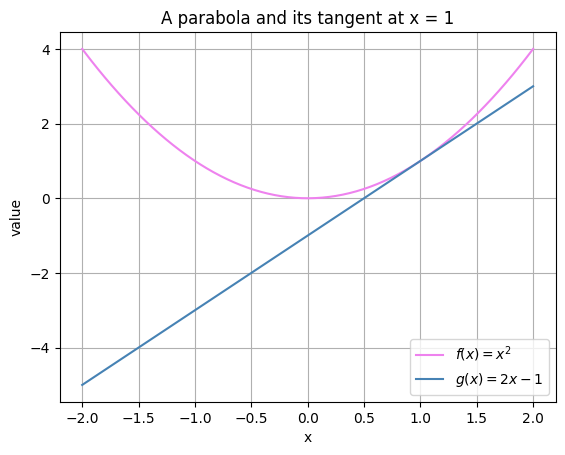

In [28]:
x = np.linspace(-2, 2, 200)

y = (x ** 2)
z = (2 * x) - 1

plt.plot(x, y, color="violet", label=r"$f(x) = x^2$")
plt.plot(x, z, color="steelblue", label=r"$g(x) = 2x - 1$")
plt.title("A parabola and its tangent at x = 1")
plt.xlabel("x"); plt.ylabel("value")
plt.legend()
plt.grid(True)
plt.show()

____
### ✍️ Exercise 2 (solution included)

Make a figure with **two stacked panels** (2 rows, 1 column). In the top panel
draw a histogram of 2000 samples from a normal distribution with mean 5 and
standard deviation 2. In the bottom panel draw a histogram of 2000 samples from
a **uniform** distribution on $[0, 10]$ (use `rng.uniform(0, 10, size=2000)`).
Give each panel a title.

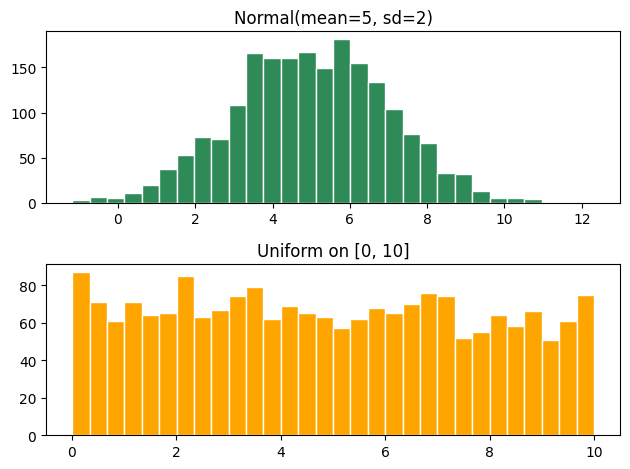

In [30]:
normal_samples = rng.normal(5, 2, size=2000)
uniform_samples = rng.uniform(0, 10, size=2000)

fig, axes = plt.subplots(2, 1)

axes[0].hist(normal_samples, bins=30, color="seagreen", edgecolor="white")
axes[0].set_title("Normal(mean=5, sd=2)")

axes[1].hist(uniform_samples, bins=30, color="orange", edgecolor="white")
axes[1].set_title("Uniform on [0, 10]")

fig.tight_layout()
plt.show()